In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

os.makedirs('figures', exist_ok=True)

# ── Colour scheme ──────────────────────────────────────────────
C_BERT    = '#4C72B0'  # muted blue
C_ROBERTA = '#DD8452'  # muted orange
C_SBERT   = '#55A868'  # muted green
C_CLEAN   = '#333333'  # dark grey for clean baseline
C_MIXED   = '#C44E52'  # muted red for mixed

# ── Global style ───────────────────────────────────────────────
plt.rcParams.update({
    'font.family'      : 'serif',
    'font.size'        : 11,
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'legend.fontsize'  : 10,
    'figure.dpi'       : 150,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linestyle'   : '--',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

print("Setup complete — figures will be saved to ./figures/")

Setup complete — figures will be saved to ./figures/


F1 Degradation Curves (clean trained):

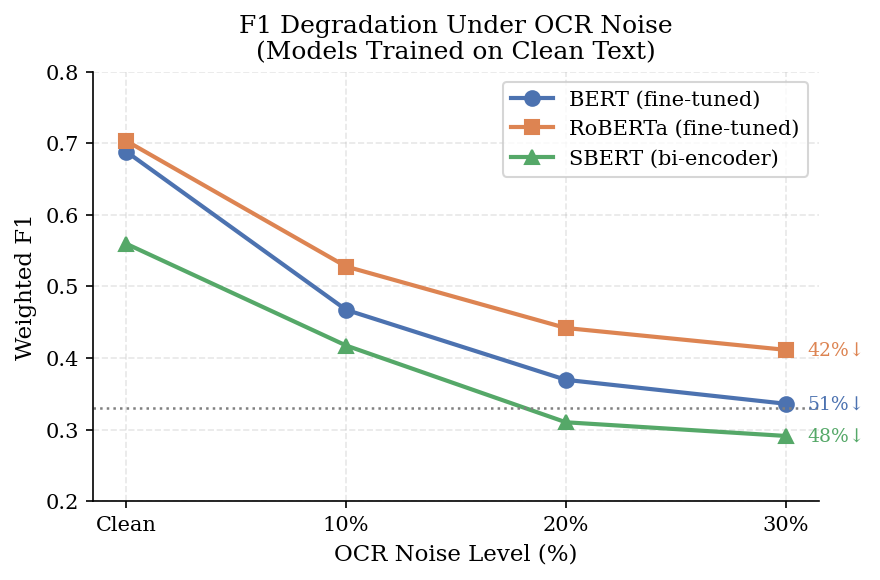

Saved: fig_f1_degradation.pdf / .png


In [5]:
noise_levels = [0, 10, 20, 30]

# Clean trained weighted F1
bert_clean_train    = [0.6881, 0.4672, 0.3694, 0.3360]
roberta_clean_train = [0.7031, 0.5277, 0.4418, 0.4113]
sbert_clean_train   = [0.5594, 0.4173, 0.3101, 0.2910]

fig, ax = plt.subplots(figsize=(6,4))

ax.plot(noise_levels, bert_clean_train,
        marker='o', linewidth=2, markersize=7,
        color=C_BERT, label='BERT (fine-tuned)')

ax.plot(noise_levels, roberta_clean_train,
        marker='s', linewidth=2, markersize=7,
        color=C_ROBERTA, label='RoBERTa (fine-tuned)')

ax.plot(noise_levels, sbert_clean_train,
        marker='^', linewidth=2, markersize=7,
        color=C_SBERT, label='SBERT (bi-encoder)')

# Annotate drop at 30%
for vals, color, name in [
    (bert_clean_train,    C_BERT,    'BERT'),
    (roberta_clean_train, C_ROBERTA, 'RoBERTa'),
    (sbert_clean_train,   C_SBERT,   'SBERT'),
]:
    drop = ((vals[0] - vals[-1]) / vals[0]) * 100
    ax.annotate(f'{drop:.0f}%↓',
                xy=(30, vals[-1]),
                xytext=(31, vals[-1]),
                fontsize=9, color=color,
                va='center')

ax.set_xlabel('OCR Noise Level (%)')
ax.set_ylabel('Weighted F1')
ax.set_title('F1 Degradation Under OCR Noise\n(Models Trained on Clean Text)')
ax.set_xticks(noise_levels)
ax.set_xticklabels(['Clean', '10%', '20%', '30%'])
ax.set_ylim(0.20, 0.80)
ax.legend(loc='upper right')
ax.axhline(y=0.33, color='grey', linestyle=':', linewidth=1.2,
           label='Random baseline (~0.33)')

plt.tight_layout()
plt.savefig('figures/fig_f1_degradation.pdf', bbox_inches='tight')
plt.savefig('figures/fig_f1_degradation.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig_f1_degradation.pdf / .png")

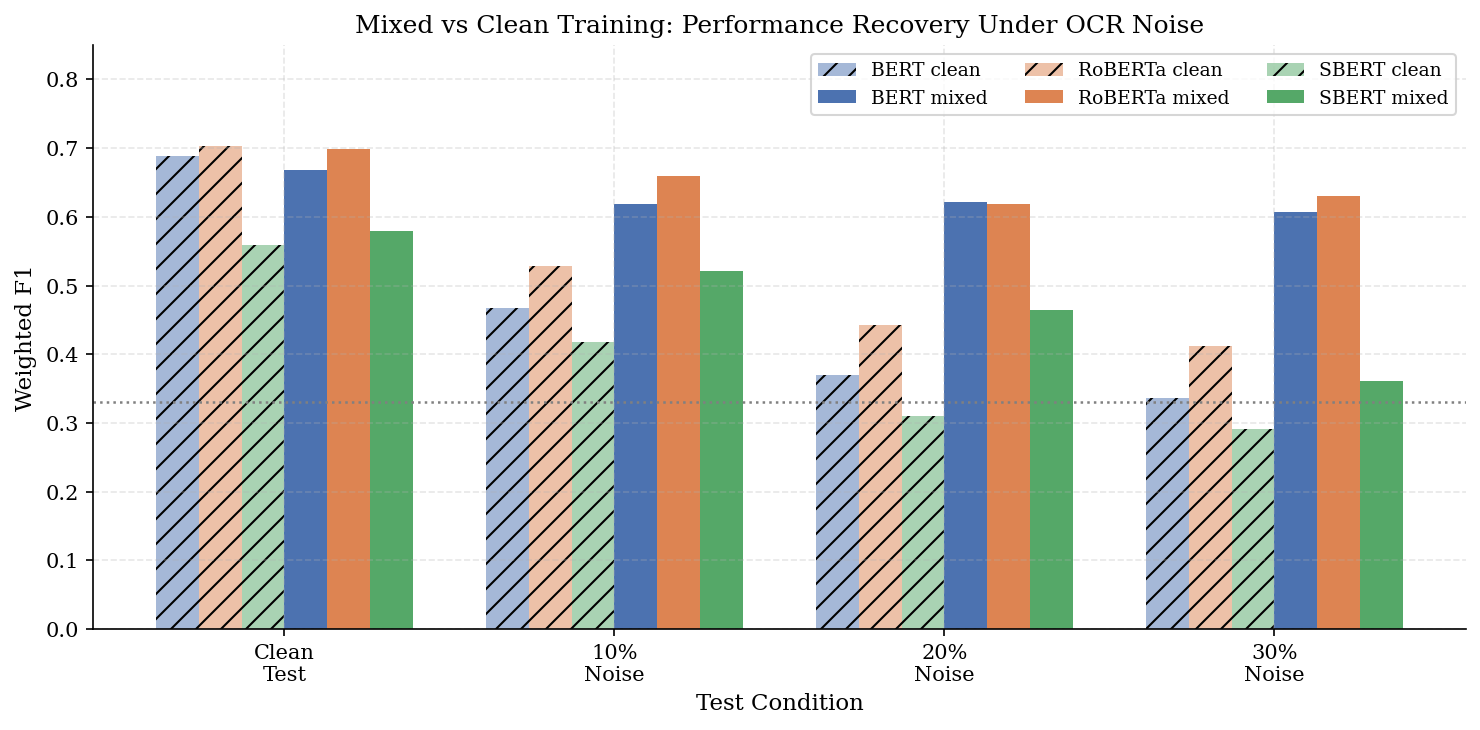

Saved: fig_mixed_vs_clean.pdf / .png


In [6]:
test_conditions = ['Clean\nTest', '10%\nNoise', '20%\nNoise', '30%\nNoise']
x = np.arange(len(test_conditions))
width = 0.13

# Clean trained
bert_clean    = [0.6881, 0.4672, 0.3694, 0.3360]
roberta_clean = [0.7031, 0.5277, 0.4418, 0.4113]
sbert_clean   = [0.5594, 0.4173, 0.3101, 0.2910]

# Mixed trained
bert_mixed    = [0.6680, 0.6189, 0.6214, 0.6075]
roberta_mixed = [0.6987, 0.6597, 0.6188, 0.6309]
sbert_mixed   = [0.5793, 0.5204, 0.4642, 0.3605]

fig, ax = plt.subplots(figsize=(10, 5))

# Clean bars (lighter shade — hatched)
ax.bar(x - 2.5*width, bert_clean,    width, color=C_BERT,
       alpha=0.5, hatch='//', label='BERT (clean train)')
ax.bar(x - 1.5*width, roberta_clean, width, color=C_ROBERTA,
       alpha=0.5, hatch='//', label='RoBERTa (clean train)')
ax.bar(x - 0.5*width, sbert_clean,   width, color=C_SBERT,
       alpha=0.5, hatch='//', label='SBERT (clean train)')

# Mixed bars (solid)
ax.bar(x + 0.5*width, bert_mixed,    width, color=C_BERT,
       alpha=1.0, label='BERT (mixed train)')
ax.bar(x + 1.5*width, roberta_mixed, width, color=C_ROBERTA,
       alpha=1.0, label='RoBERTa (mixed train)')
ax.bar(x + 2.5*width, sbert_mixed,   width, color=C_SBERT,
       alpha=1.0, label='SBERT (mixed train)')

ax.set_xlabel('Test Condition')
ax.set_ylabel('Weighted F1')
ax.set_title('Mixed vs Clean Training: Performance Recovery Under OCR Noise')
ax.set_xticks(x)
ax.set_xticklabels(test_conditions)
ax.set_ylim(0, 0.85)
ax.axhline(y=0.33, color='grey', linestyle=':', linewidth=1.2)

# Custom legend
handles = [
    mpatches.Patch(facecolor=C_BERT,    alpha=0.5, hatch='//', label='BERT clean'),
    mpatches.Patch(facecolor=C_BERT,    alpha=1.0, label='BERT mixed'),
    mpatches.Patch(facecolor=C_ROBERTA, alpha=0.5, hatch='//', label='RoBERTa clean'),
    mpatches.Patch(facecolor=C_ROBERTA, alpha=1.0, label='RoBERTa mixed'),
    mpatches.Patch(facecolor=C_SBERT,   alpha=0.5, hatch='//', label='SBERT clean'),
    mpatches.Patch(facecolor=C_SBERT,   alpha=1.0, label='SBERT mixed'),
]
ax.legend(handles=handles, ncol=3, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('figures/fig_mixed_vs_clean.pdf', bbox_inches='tight')
plt.savefig('figures/fig_mixed_vs_clean.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig_mixed_vs_clean.pdf / .png")

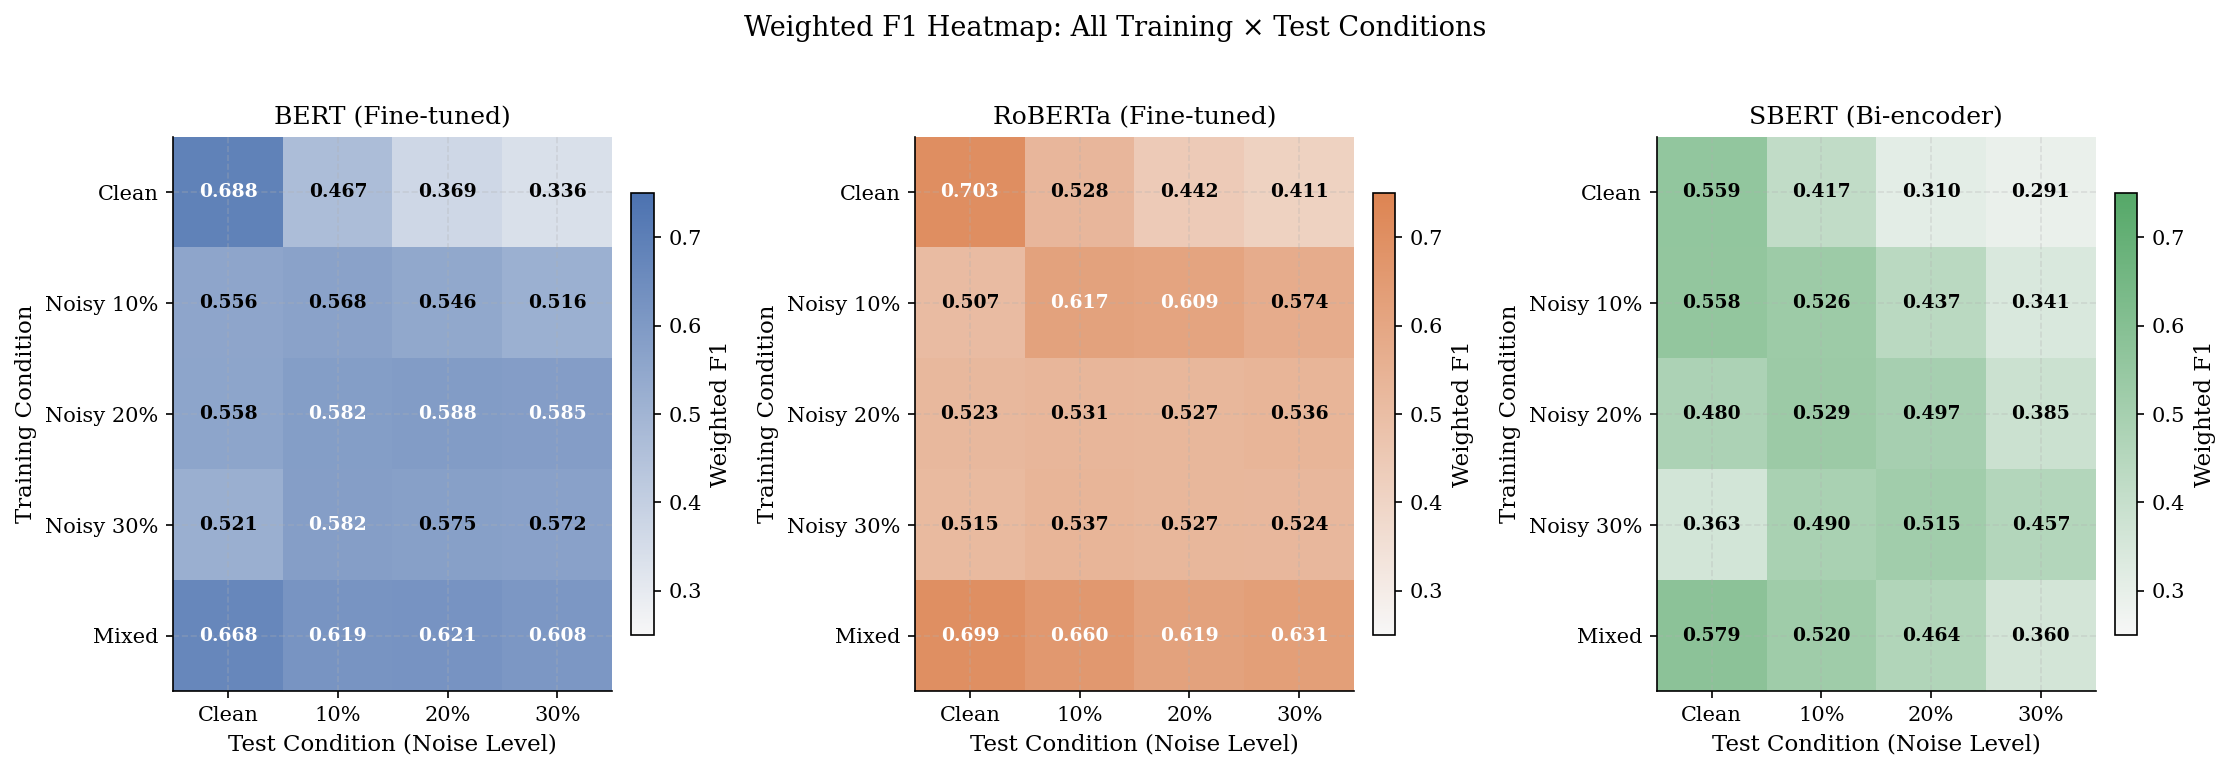

Saved: fig_heatmaps.pdf / .png


In [7]:
import matplotlib.colors as mcolors

train_labels = ['Clean', 'Noisy 10%', 'Noisy 20%', 'Noisy 30%', 'Mixed']
test_labels  = ['Clean', '10%', '20%', '30%']

# Weighted F1 matrices
bert_matrix = np.array([
    [0.6881, 0.4672, 0.3694, 0.3360],
    [0.5558, 0.5679, 0.5462, 0.5165],
    [0.5581, 0.5824, 0.5883, 0.5854],
    [0.5211, 0.5815, 0.5747, 0.5721],
    [0.6680, 0.6189, 0.6214, 0.6075],
])

roberta_matrix = np.array([
    [0.7031, 0.5277, 0.4418, 0.4113],
    [0.5066, 0.6173, 0.6087, 0.5741],
    [0.5226, 0.5308, 0.5273, 0.5356],
    [0.5147, 0.5371, 0.5270, 0.5236],
    [0.6987, 0.6597, 0.6188, 0.6309],
])

sbert_matrix = np.array([
    [0.5594, 0.4173, 0.3101, 0.2910],
    [0.5578, 0.5257, 0.4368, 0.3414],
    [0.4799, 0.5293, 0.4973, 0.3854],
    [0.3632, 0.4899, 0.5153, 0.4572],
    [0.5793, 0.5204, 0.4642, 0.3605],
])

matrices = [
    (bert_matrix,    'BERT (Fine-tuned)',    C_BERT),
    (roberta_matrix, 'RoBERTa (Fine-tuned)', C_ROBERTA),
    (sbert_matrix,   'SBERT (Bi-encoder)',   C_SBERT),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (matrix, title, color) in zip(axes, matrices):
    # Create colormap from white to model color
    cmap = mcolors.LinearSegmentedColormap.from_list(
        'custom', ['#f7f7f7', color], N=256
    )

    im = ax.imshow(matrix, cmap=cmap, vmin=0.25, vmax=0.75, aspect='auto')

    # Annotate cells
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            val = matrix[i, j]
            text_color = 'white' if val > 0.58 else 'black'
            ax.text(j, i, f'{val:.3f}',
                    ha='center', va='center',
                    fontsize=9, color=text_color, fontweight='bold')

    ax.set_xticks(range(len(test_labels)))
    ax.set_xticklabels(test_labels)
    ax.set_yticks(range(len(train_labels)))
    ax.set_yticklabels(train_labels)
    ax.set_xlabel('Test Condition (Noise Level)')
    ax.set_ylabel('Training Condition')
    ax.set_title(title)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                 label='Weighted F1')

plt.suptitle('Weighted F1 Heatmap: All Training × Test Conditions',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('figures/fig_heatmaps.pdf', bbox_inches='tight')
plt.savefig('figures/fig_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig_heatmaps.pdf / .png")

<>:30: SyntaxWarning: invalid escape sequence '\D'
<>:30: SyntaxWarning: invalid escape sequence '\D'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_41804\2149974773.py:30: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel('F1 Recovery ($\Delta$ Mixed $-$ Clean Training)')


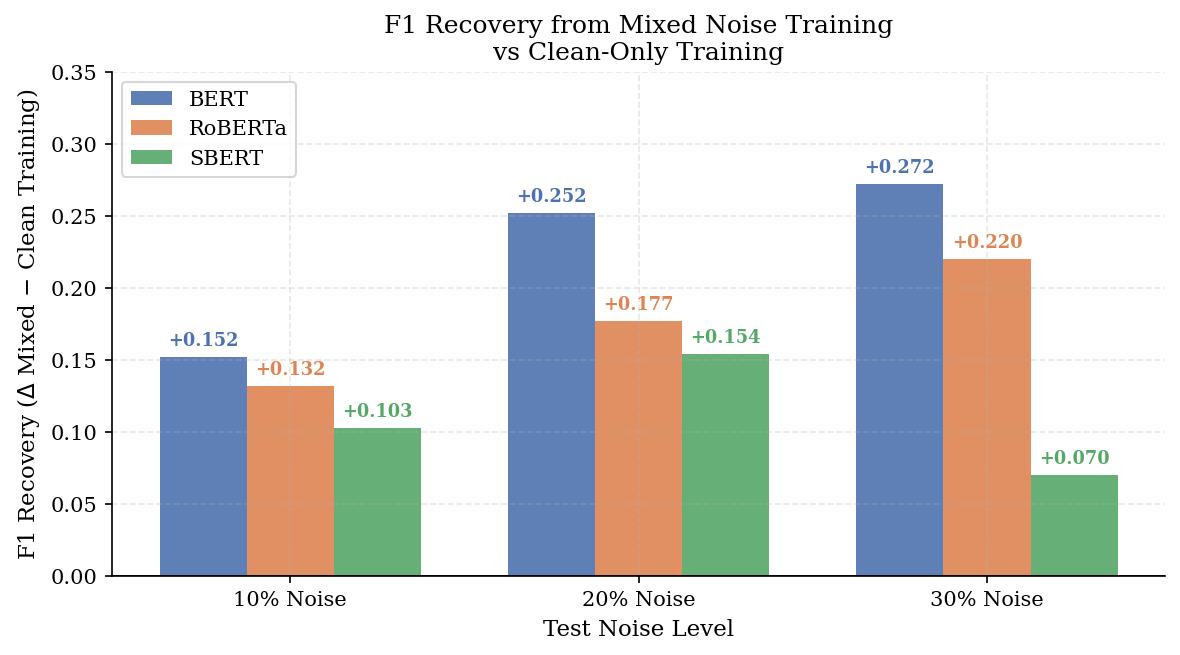

Saved: fig_recovery_delta.pdf / .png


In [8]:
models  = ['BERT', 'RoBERTa', 'SBERT']
noise   = ['10% Noise', '20% Noise', '30% Noise']
colors  = [C_BERT, C_ROBERTA, C_SBERT]

# Delta = mixed - clean trained at each noise level
deltas = {
    'BERT'   : [0.619-0.467, 0.621-0.369, 0.608-0.336],
    'RoBERTa': [0.660-0.528, 0.619-0.442, 0.631-0.411],
    'SBERT'  : [0.520-0.417, 0.464-0.310, 0.361-0.291],
}

x     = np.arange(len(noise))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 4.5))

for i, (model, color) in enumerate(zip(models, colors)):
    vals = deltas[model]
    bars = ax.bar(x + (i-1)*width, vals, width,
                  color=color, label=model, alpha=0.9)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'+{val:.3f}',
                ha='center', va='bottom',
                fontsize=8.5, color=color, fontweight='bold')

ax.set_xlabel('Test Noise Level')
ax.set_ylabel('F1 Recovery ($\Delta$ Mixed $-$ Clean Training)')
ax.set_title('F1 Recovery from Mixed Noise Training\nvs Clean-Only Training')
ax.set_xticks(x)
ax.set_xticklabels(noise)
ax.set_ylim(0, 0.35)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('figures/fig_recovery_delta.pdf', bbox_inches='tight')
plt.savefig('figures/fig_recovery_delta.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig_recovery_delta.pdf / .png")